In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt

from src.analysis import run_monte_carlo
from src.config import variable_names
from src.core import Variable
from src.models import OperatingIncomeModel, NetIncomeModel, MarketPriceModel
from src.variables import PriceToEarningsRatio
from src.visualization import generate_histogram_from_array
from src.utils import plot_multiple_views

In [2]:
variables = {
    variable_names.REVENUE: Variable(min=80000.0, exp=100000.0, max=120000.0),
    variable_names.COGS: Variable(min=30000.0, exp=40000.0, max=50000.0),
    variable_names.PE_RATIO: PriceToEarningsRatio(min=5.0, exp=8.0, max=10.0)
}

pipeline = [OperatingIncomeModel(), NetIncomeModel(), MarketPriceModel()]

In [3]:
monte_carlo_simulation_report = run_monte_carlo(
    variables=variables,
    shuffled_inputs=[variable_names.REVENUE, variable_names.COGS, variable_names.PE_RATIO],
    model_pipeline=pipeline,
    iterations=50
)

# print(monte_carlo_simulation_report)

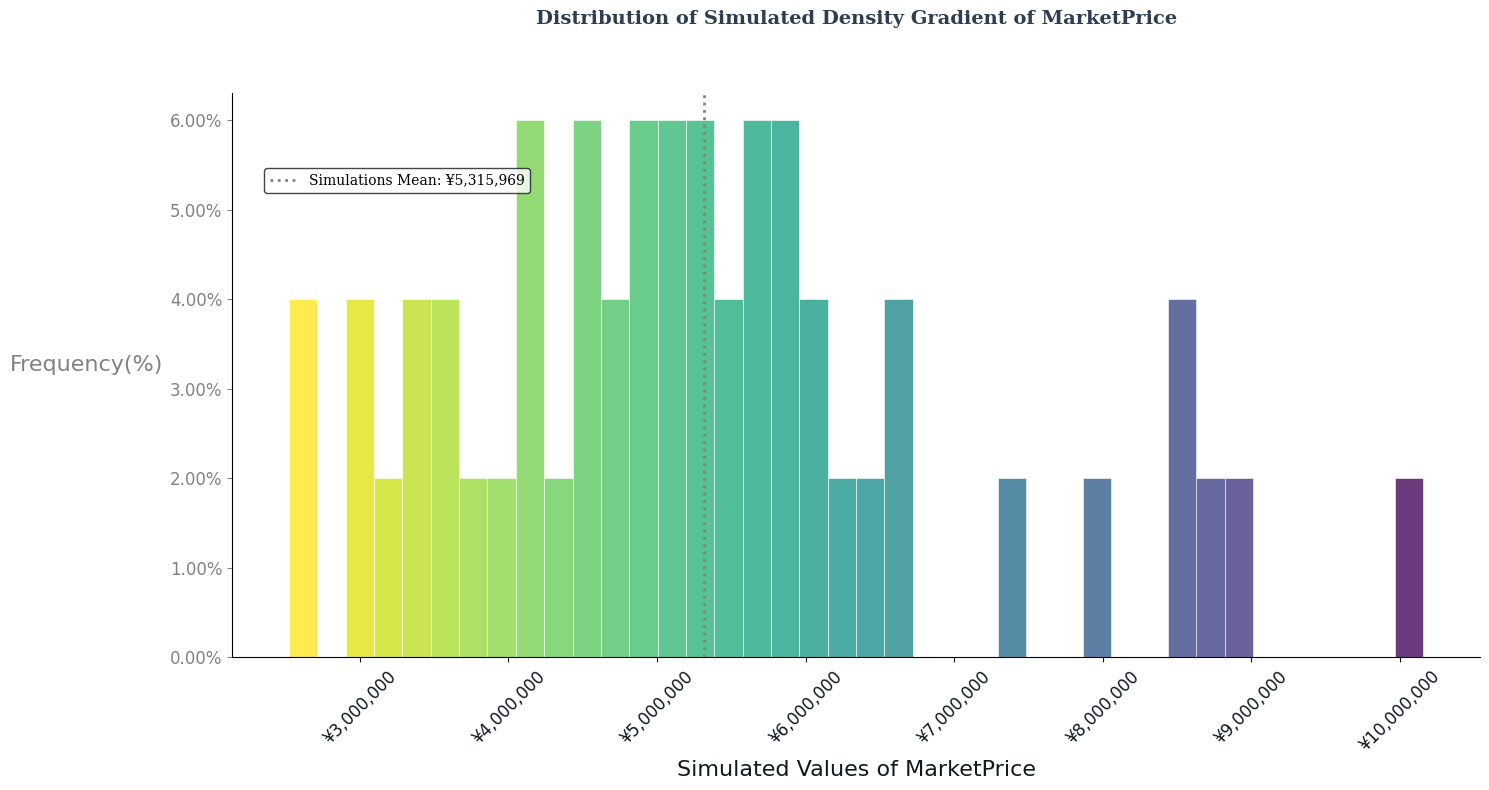

In [4]:
generate_histogram_from_array(monte_carlo_simulation_report, variable_names.MARKET_PRICE)
plt.show()

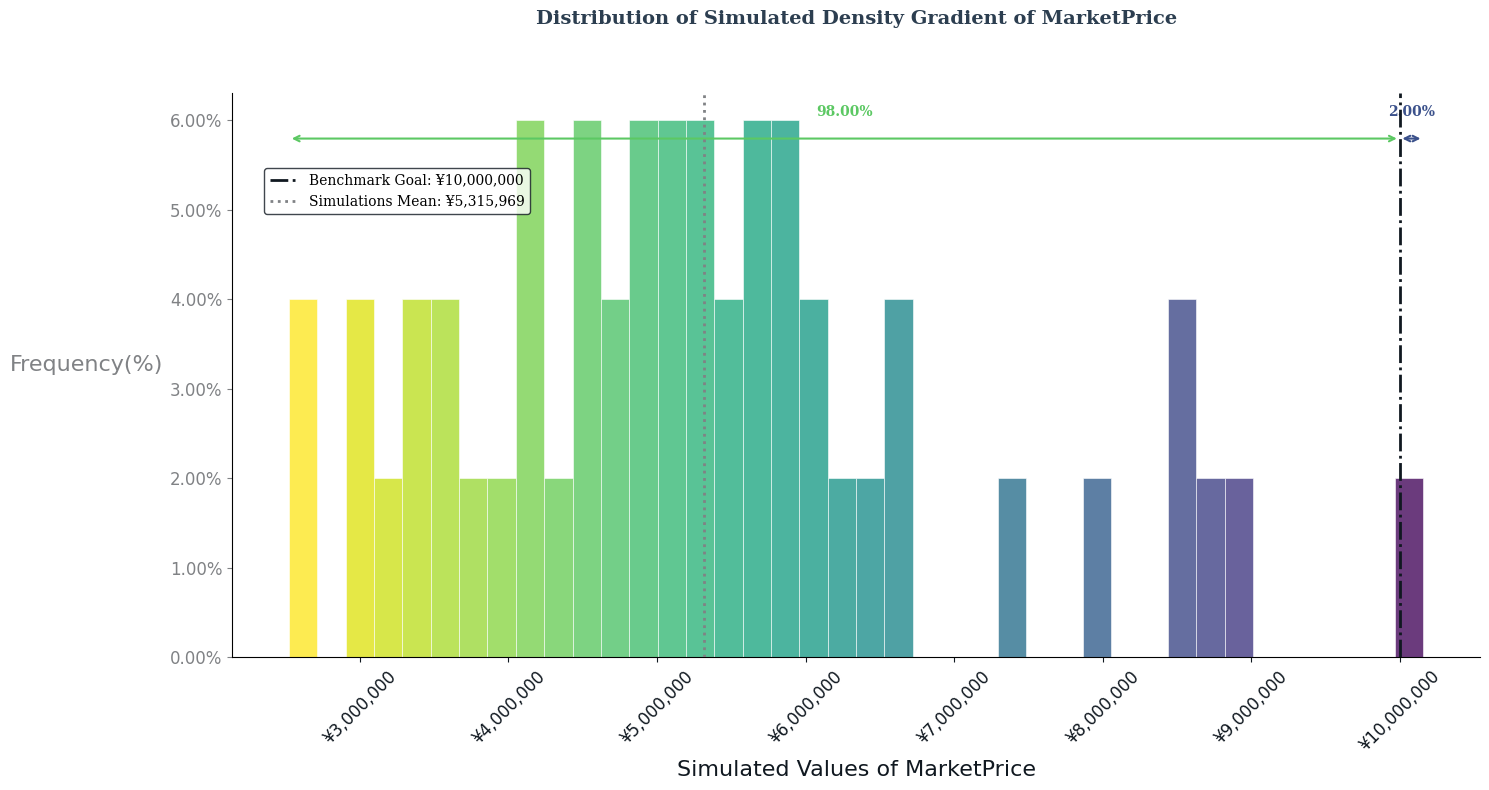

In [5]:
generate_histogram_from_array(monte_carlo_simulation_report, variable_names.MARKET_PRICE, goal=10000000)
plt.show()

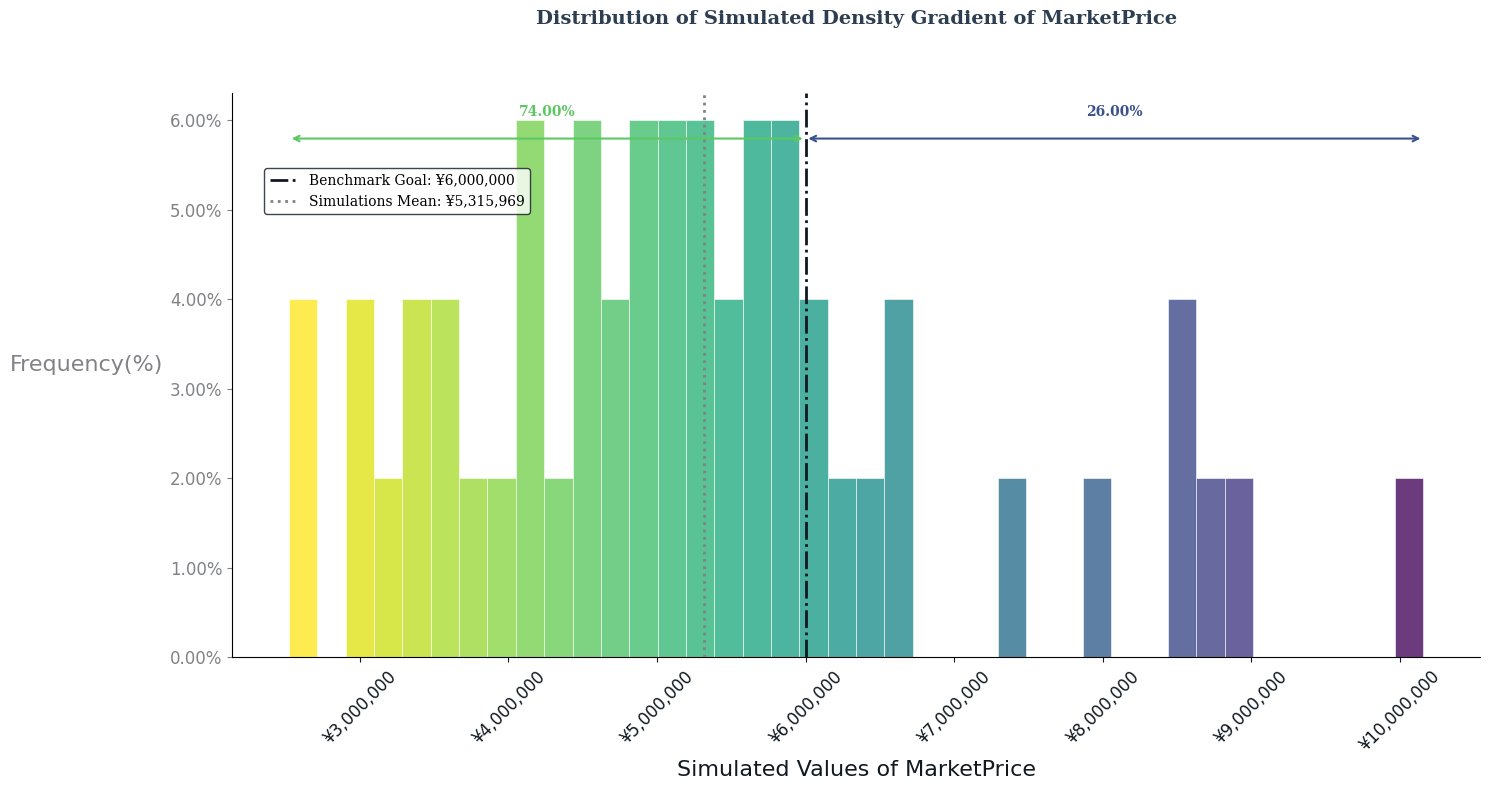

In [6]:
generate_histogram_from_array(monte_carlo_simulation_report, variable_names.MARKET_PRICE, goal=6000000)
plt.show()

In [7]:
plt.close()

In [12]:
plot_functions = [
    lambda ax: generate_histogram_from_array(monte_carlo_simulation_report, variable_names.MARKET_PRICE, ax=ax, title="Market Price"),
    lambda ax: generate_histogram_from_array(monte_carlo_simulation_report, variable_names.MARKET_PRICE, goal=6000000, ax=ax),
    # lambda ax: generate_histogram_from_array(monte_carlo_simulation_report, variable_names.MARKET_PRICE, goal=6000000, ax=ax),
]

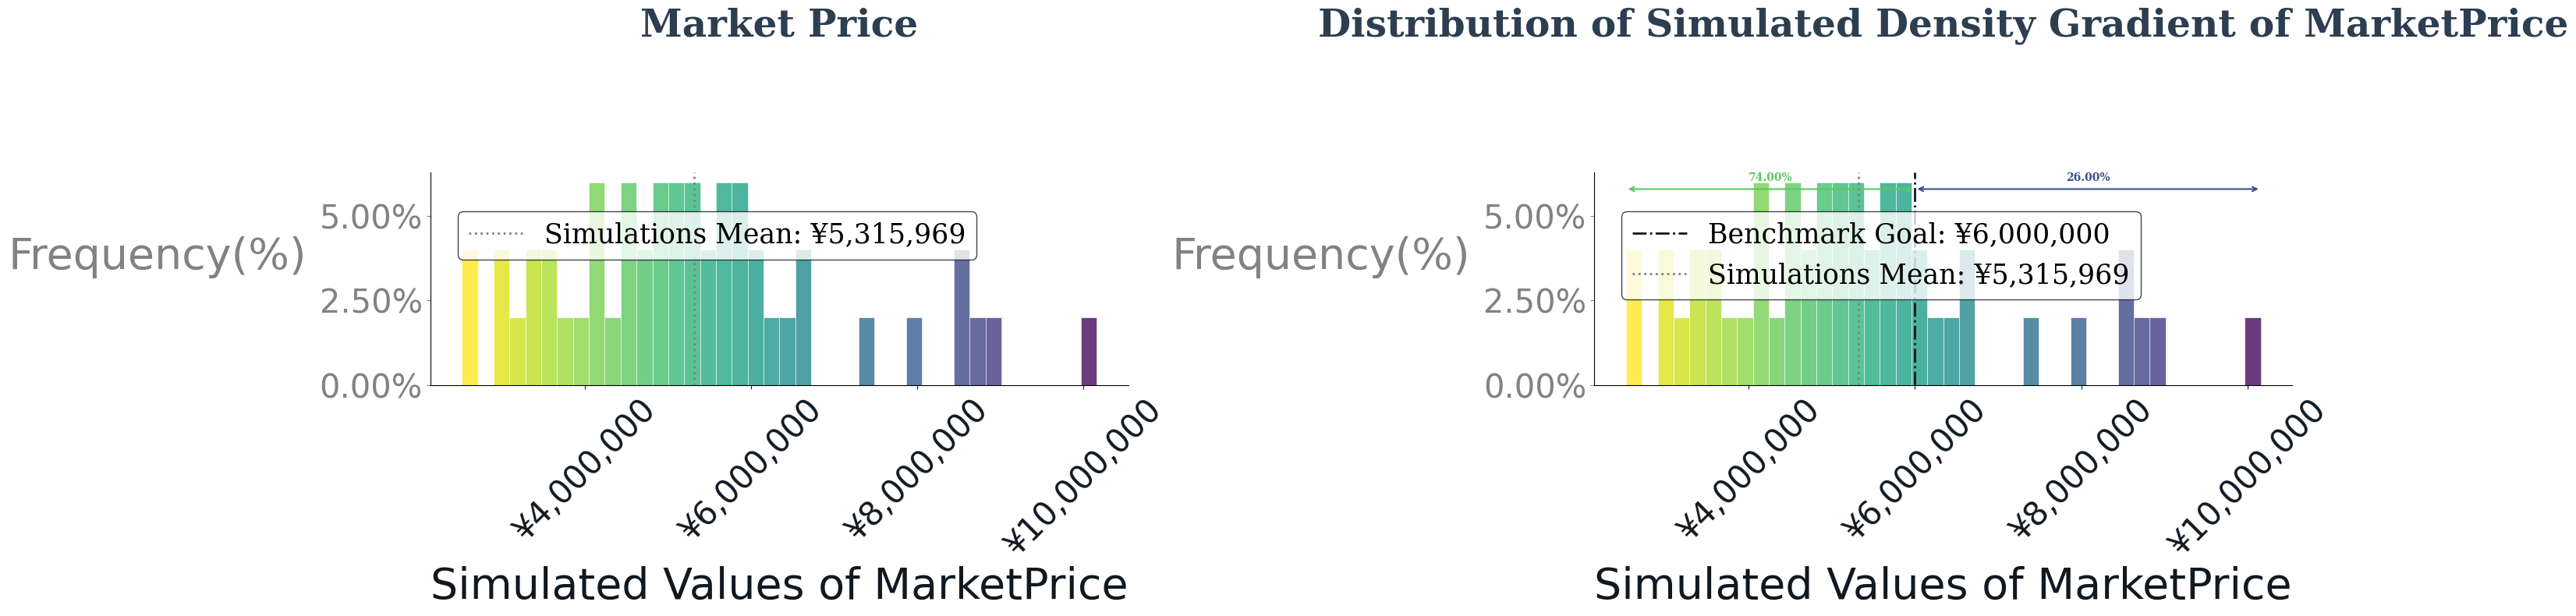

In [13]:
fig = plot_multiple_views(plot_functions)

In [11]:
plt.close()